# Zomato Bangalore Restaurant Insights: Ratings, Online Ordering, and Dining Trends

In [9]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Importing data from the database
# 1. Opening a connection to a SQLite database file

con = sqlite3.connect(r"/Users/claudinha/Portfolio/Zomato_Case_of_Study/zomato_rawdata.sqlite")

In [11]:
# 2. Running a SQL query on the database connection ("geting all columns from the Users table")
df = pd.read_sql_query("SELECT * FROM Users", con)

In [12]:
# Cleaning data
# Dealing with missing values
df.isnull().sum() #finding the number of null values for each variable

index                              0
url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [13]:
# Finding the percentage of missing values for each variable
df.isnull().sum()/(len(df))*100

index                           0.000000
url                             0.000000
address                         0.000000
name                            0.000000
online_order                    0.000000
book_table                      0.000000
rate                           15.033741
votes                           0.000000
phone                           2.335789
location                        0.040606
rest_type                       0.438927
dish_liked                     54.291626
cuisines                        0.087012
approx_cost(for two people)     0.669026
reviews_list                    0.000000
menu_item                       0.000000
listed_in(type)                 0.000000
listed_in(city)                 0.000000
dtype: float64

In [14]:
# Finding out the unique values in the "rate" variable (checking how missing values look like)
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', None, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [15]:
# Replacing missing data
df['rate'].replace(('NEW', '-'), np.nan, inplace = True)

/var/folders/q3/rsyd34v93rd8xdld41qxtddm0000gn/T/ipykernel_12507/2883249852.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rate'].replace(('NEW', '-'), np.nan, inplace = True)


In [16]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', nan, '2.9/5', '3.5/5', None, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [17]:
# The rate column is not yet in the correct format, it is necessary to get rid of the '/5' after each rate
df['rate'] = df['rate'].apply(lambda x: float(x.split('/')[0]) if type(x) == str else x)

In [18]:
df['rate']

0        4.1
1        4.1
2        3.8
3        3.7
4        3.8
        ... 
51712    3.6
51713    NaN
51714    NaN
51715    4.3
51716    3.4
Name: rate, Length: 51717, dtype: float64

# Is there a relation beteween online order option and rating of the restaurant?

In [19]:
# Creating a table with the combination of rating (`rate`) and online ordering availability (`online_order`).
x = pd.crosstab(df['rate'], df['online_order'])
x

online_order,No,Yes
rate,,
1.8,5,0
2.0,11,0
2.1,9,15
2.2,10,16
2.3,29,22
2.4,36,34
2.5,38,63
2.6,83,177
2.7,141,166


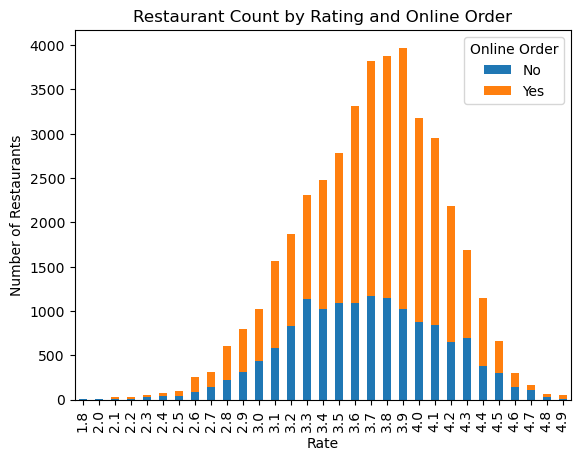

In [20]:
# Stacked bar to show the results
ax = x.plot(kind = 'bar', stacked = True)

ax.set_title('Restaurant Count by Rating and Online Order')
ax.set_xlabel('Rate')
ax.set_ylabel('Number of Restaurants')
plt.legend(title='Online Order')

In [21]:
# Creatng a table with percentages 
x.sum(axis = 1).astype(float)
normalized_data = x.div(x.sum(axis = 1).astype(float), axis = 0)
normalized_data = normalized_data*100
normalized_data

online_order,No,Yes
rate,,
1.8,100.000000,0.000000
2.0,100.000000,0.000000
2.1,37.500000,62.500000
2.2,38.461538,61.538462
2.3,56.862745,43.137255
2.4,51.428571,48.571429
2.5,37.623762,62.376238
2.6,31.923077,68.076923
2.7,45.928339,54.071661


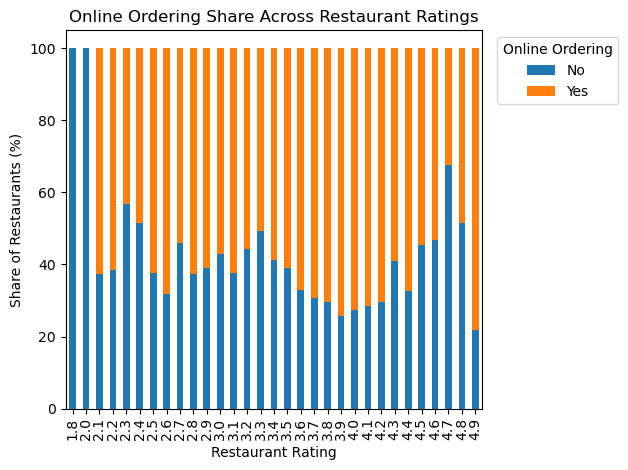

In [22]:
# Stacked bar to show percentage split by rating
ax = normalized_data.plot(kind = 'bar', stacked = True)

ax.set_title('Online Ordering Share Across Restaurant Ratings')
ax.set_xlabel('Restaurant Rating')
ax.set_ylabel('Share of Restaurants (%)')
ax.legend(title='Online Ordering', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

Conclusion: Restaurants with online ordering tend to have higher ratings in this dataset.

In [23]:
# Data text cleaning
# Verifying null values
df['rest_type'].isnull().sum()

227

In [24]:
# Removing null values
data = df.dropna(subset = ['rest_type'])
data['rest_type'].isnull().sum()

0

In [25]:
# The text analysis will be performed for just a restaurant, the whole dataset is huge
quick_bites_df = data[data['rest_type'].str.contains('Quick Bites')]


In [26]:
quick_bites_df.head()

,index,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
3,3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
23,23,https://www.zomato.com/bangalore/my-tea-house-...,"224/Y, 4th Phase, 7th Block, 100 Feet Ring Roa...",My Tea House,Yes,No,3.6,62,080 65975430\r\n+91 7337733798,Banashankari,"Quick Bites, Cafe","Pasta, Iced Tea","Italian, Fast Food, Cafe, European",600,"[('Rated 4.0', ""RATED\n So, went here with fr...",[],Cafes,Banashankari
26,26,https://www.zomato.com/bangalore/coffee-tindi-...,"27th Cross Rd, Banashankari Stage II, Banashan...",Coffee Tindi,Yes,No,3.8,75,+91 9945758046,Banashankari,"Cafe, Quick Bites",None,"Cafe, South Indian",200,"[('Rated 5.0', 'RATED\n please provide some e...",[],Cafes,Banashankari
31,31,https://www.zomato.com/bangalore/foodiction-1-...,"2/1, 7th Main, Dwarakangar, Hosakeregalli, Ban...",Foodiction,Yes,No,2.8,506,+91 9916107070,Banashankari,Quick Bites,"Burgers, Lassi, Chicken Grill, Naan, Momos, Ch...","North Indian, Fast Food, Chinese, Burger",500,"[('Rated 1.0', ""RATED\n Worst restaurant ever...",[],Delivery,Banashankari
34,34,https://www.zomato.com/bangalore/faasos-banash...,"80, BDA Complex, 2nd Stage, Banashankari, Bang...",Faasos,Yes,No,4.2,415,+91 7700020020,Banashankari,Quick Bites,"Rolls, Veggie Wrap, Chocolate Fantasy, Rice Bo...","North Indian, Biryani, Fast Food",500,"[('Rated 3.0', 'RATED\n Not worth for the mon...","['Chole Kulcha Meal', 'Upvas Aloo Paratha With...",Delivery,Banashankari


In [27]:
# Getting every review in lower case
quick_bites_df['reviews_list'] = quick_bites_df['reviews_list'].apply(lambda x: x.lower())

/var/folders/q3/rsyd34v93rd8xdld41qxtddm0000gn/T/ipykernel_12507/3680063391.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  quick_bites_df['reviews_list'] = quick_bites_df['reviews_list'].apply(lambda x: x.lower())


In [28]:
# Initialize a tokenizer to extract only alphabetic words (ignore numbers and symbols)
from nltk import RegexpTokenizer
tokenizer = RegexpTokenizer('[a-zA-Z]+')

In [29]:
# Applying the tokenizer in each line
tokenizer.tokenize(quick_bites_df['reviews_list'][3])

['rated',
 'rated',
 'n',
 'great',
 'food',
 'and',
 'proper',
 'karnataka',
 'style',
 'full',
 'meals',
 'been',
 'there',
 'twice',
 'and',
 'was',
 'fully',
 'satisfied',
 'will',
 'give',
 'stars',
 'if',
 'it',
 's',
 'well',
 'managed',
 'rated',
 'rated',
 'n',
 'reached',
 'the',
 'place',
 'at',
 'pm',
 'on',
 'saturday',
 'half',
 'of',
 'the',
 'items',
 'on',
 'the',
 'menu',
 'were',
 'over',
 'what',
 'was',
 'annoying',
 'was',
 'is',
 'the',
 'food',
 'was',
 'cold',
 'the',
 'taste',
 'was',
 'also',
 'very',
 'average',
 'only',
 'dosa',
 'and',
 'holige',
 'were',
 'good',
 'there',
 'were',
 'very',
 'few',
 'people',
 'in',
 'the',
 'restaurant',
 'and',
 'the',
 'service',
 'was',
 'still',
 'very',
 'slow',
 'the',
 'waiters',
 'were',
 'all',
 'standing',
 'in',
 'one',
 'corner',
 'and',
 'talking',
 'had',
 'to',
 'call',
 'them',
 'repeatedly',
 'rated',
 'rated',
 'n',
 'had',
 'been',
 'here',
 'good',
 'food',
 'served',
 'and',
 'tasty',
 'good',
 'plac

In [30]:
# Making a sample of the data
sample = data[0:1000]
reviews_tokens = sample['reviews_list'].apply(tokenizer.tokenize)
reviews_tokens

0       [Rated, RATED, n, A, beautiful, place, to, din...
1       [Rated, RATED, n, Had, been, here, for, dinner...
2       [Rated, RATED, n, Ambience, is, not, that, goo...
3       [Rated, RATED, n, Great, food, and, proper, Ka...
4       [Rated, RATED, n, Very, good, restaurant, in, ...
                              ...                        
995     [Rated, RATED, n, Ideal, for, quick, neighborh...
996     [Rated, RATED, n, We, ordered, for, Alankrutha...
997     [Rated, RATED, n, This, review, should, have, ...
998     [Rated, RATED, n, We, tried, Chicken, Shawarma...
1000    [Rated, RATED, n, An, authentic, Andhra, cuisi...
Name: reviews_list, Length: 1000, dtype: object

In [31]:
# Performing Unigram analysis and removal of stopwords
from nltk.corpus import stopwords
stop = stopwords.words('english')
#Extending the list of words
stop.extend(['rated', 'n', 'nan', 'x', 'RATED', 'Rated'])


In [32]:
# Vizualizating the list of stop words
print(stop)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [33]:
#Testing the removal of stop words:
rev3 = reviews_tokens[3]
[token for token in rev3 if token not in stop]


['Great',
 'food',
 'proper',
 'Karnataka',
 'style',
 'full',
 'meals',
 'Been',
 'twice',
 'fully',
 'satisfied',
 'Will',
 'give',
 'stars',
 'well',
 'managed',
 'Reached',
 'place',
 'pm',
 'Saturday',
 'Half',
 'items',
 'menu',
 'What',
 'annoying',
 'food',
 'cold',
 'The',
 'taste',
 'also',
 'average',
 'Only',
 'dosa',
 'holige',
 'good',
 'There',
 'people',
 'restaurant',
 'service',
 'still',
 'slow',
 'The',
 'waiters',
 'standing',
 'one',
 'corner',
 'talking',
 'Had',
 'call',
 'repeatedly',
 'Had',
 'good',
 'food',
 'served',
 'tasty',
 'good',
 'place',
 'go',
 'freinds',
 'family',
 'first',
 'get',
 'served',
 'well',
 'food',
 'One',
 'good',
 'hotel',
 'price',
 'How',
 'Udupi',
 'restaurant',
 'dirty',
 'floor',
 'walls',
 'waiters',
 'stained',
 'food',
 'Why',
 'cant',
 'clean',
 'The',
 'floor',
 'even',
 'decorative',
 'colour',
 'paper',
 'every',
 'lot',
 'food',
 'Now',
 'coming',
 'taste',
 'food',
 'pretty',
 'decent',
 'chargw',
 'What',
 'upset',
 '

In [34]:
# Removing all stop words from all the reviews
reviews_tokens_clean = reviews_tokens.apply(lambda each_review: [token for token in each_review if token not in stop])
reviews_tokens_clean

0       [A, beautiful, place, dine, The, interiors, ta...
1       [Had, dinner, family, Turned, good, choose, su...
2       [Ambience, good, enough, pocket, friendly, caf...
3       [Great, food, proper, Karnataka, style, full, ...
4       [Very, good, restaurant, neighbourhood, Buffet...
                              ...                        
995     [Ideal, quick, neighborhood, bite, Has, good, ...
996     [We, ordered, Alankrutha, Special, Biryani, Mu...
997     [This, review, posted, year, ago, better, late...
998     [We, tried, Chicken, Shawarma, Some, Panner, G...
1000    [An, authentic, Andhra, cuisine, restaurant, s...
Name: reviews_list, Length: 1000, dtype: object

In [35]:
# Convert the cleaned token generator into a list to display all results
total_reviews_2D = list(reviews_tokens_clean)


In [36]:
# Taking all the individual word tokens from all reviews and puts them into a single flat list 
total_reviews_1D = []
for reviews in total_reviews_2D:
    for word in reviews:
        total_reviews_1D.append(word)


<Axes: title={'center': 'Top 20 Most Frequent Words in Quick Bites Reviews'}, xlabel='Samples', ylabel='Counts'>

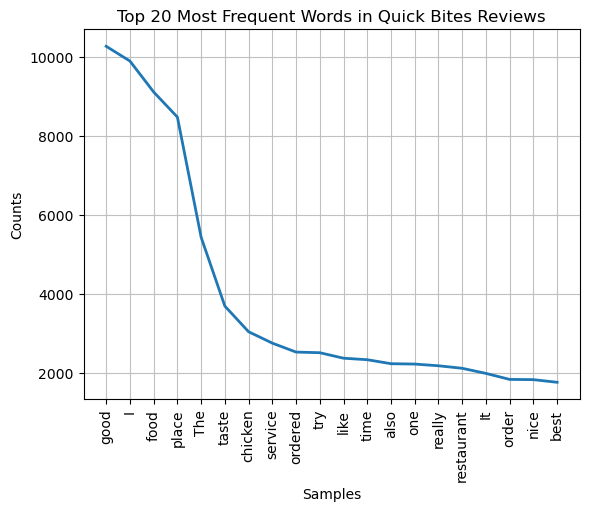

In [37]:
# Count word frequency across all reviews using NLTK's FreqDist
from nltk import FreqDist
fd = FreqDist()

for word in total_reviews_1D:
    fd[word] = fd[word] + 1

fd.most_common(20)
fd.plot(20, title='Top 20 Most Frequent Words in Quick Bites Reviews')



In [38]:
# Performing Bi-gram and Trigram analysis on data
from nltk import FreqDist, bigrams, trigrams

In [39]:
# Generate bigrams (consecutive word pairs) and count their frequency across all reviews
bi_grams = bigrams(total_reviews_1D)
fd_bigrams = FreqDist()

for bigram in bi_grams:
    fd_bigrams[bigram] = fd_bigrams[bigram] + 1

In [40]:
fd_bigrams.most_common(20)

[(('I', 'ordered'), 898),
 (('really', 'good'), 713),
 (('must', 'try'), 605),
 (('This', 'place'), 532),
 (('The', 'food'), 506),
 (('food', 'good'), 445),
 (('I', 'would'), 418),
 (('visit', 'place'), 408),
 (('fried', 'rice'), 403),
 (('good', 'food'), 403),
 (('ice', 'cream'), 395),
 (('good', 'place'), 390),
 (('taste', 'good'), 379),
 (('non', 'veg'), 374),
 (('also', 'good'), 366),
 (('I', 'tried'), 355),
 (('place', 'I'), 336),
 (('food', 'I'), 329),
 (('main', 'course'), 318),
 (('good', 'taste'), 306)]

<Axes: title={'center': 'Top 20 Most Frequent Bi-grams in Quick Bites Reviews'}, xlabel='Samples', ylabel='Counts'>

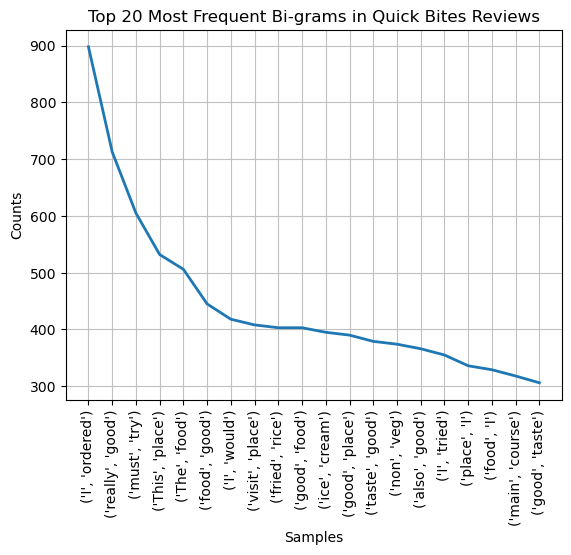

In [41]:
fd_bigrams.plot(20, title='Top 20 Most Frequent Bi-grams in Quick Bites Reviews')


In [42]:
# Generate trigrams (consecutive 3 words) and count their frequency across all reviews
tri_grams = trigrams(total_reviews_1D)
fd_trigrams = FreqDist()

for trigram in tri_grams:
    fd_trigrams[trigram ] = fd_trigrams[trigram ] + 1



In [43]:
fd_trigrams.most_common(50)

[(('paneer', 'tikka', 'biriyani'), 88),
 (('veg', 'non', 'veg'), 80),
 (('I', 'ordered', 'food'), 75),
 (('south', 'Indian', 'food'), 74),
 (('must', 'visit', 'place'), 72),
 (('I', 'would', 'recommend'), 63),
 (('The', 'food', 'good'), 63),
 (('paneer', 'butter', 'masala'), 62),
 (('Good', 'food', 'Good'), 60),
 (('I', 'ordered', 'chicken'), 60),
 (('delious', 'good', 'need'), 58),
 (('good', 'need', 'sum'), 58),
 (('need', 'sum', 'spacy'), 58),
 (('sum', 'spacy', 'food'), 58),
 (('spacy', 'food', 'bangnda'), 58),
 (('food', 'bangnda', 'fry'), 58),
 (('bangnda', 'fry', 'received'), 58),
 (('fry', 'received', 'Nice'), 58),
 (('I', 'visited', 'place'), 57),
 (('The', 'ambience', 'good'), 56),
 (('A', 'good', 'place'), 56),
 (('Taiwanese', 'baby', 'corn'), 56),
 (('main', 'course', 'ordered'), 56),
 (('received', 'Nice', 'delious'), 55),
 (('Nice', 'delious', 'good'), 55),
 (('nService', 'nValue', 'money'), 54),
 (('The', 'staff', 'friendly'), 53),
 (('I', 'must', 'say'), 52),
 (('The', 

<Axes: title={'center': 'Top 20 Most Frequent Trigrams in Quick Bites Reviews'}, xlabel='Samples', ylabel='Counts'>

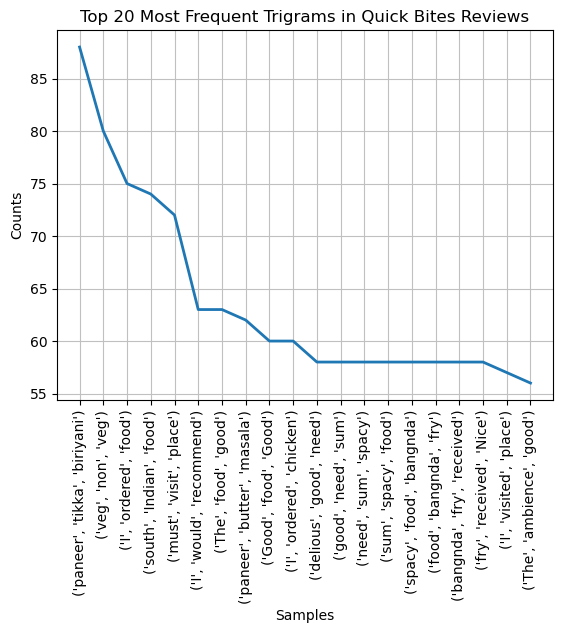

In [44]:
fd_trigrams.plot(20, title='Top 20 Most Frequent Trigrams in Quick Bites Reviews')


In [45]:
# Extract geographical coordinates from data

In [46]:
!pip install geocoder
!pip install geopy

In [47]:
len(df['location'].unique())

94

In [48]:
# Append city and state to each location entry to build full address strings for geocoding
df['location'] = df['location'] + " , Bangalore,  Karnataka, India "

In [49]:
df['location'].unique()

array(['Banashankari , Bangalore,  Karnataka, India ',
       'Basavanagudi , Bangalore,  Karnataka, India ',
       'Mysore Road , Bangalore,  Karnataka, India ',
       'Jayanagar , Bangalore,  Karnataka, India ',
       'Kumaraswamy Layout , Bangalore,  Karnataka, India ',
       'Rajarajeshwari Nagar , Bangalore,  Karnataka, India ',
       'Vijay Nagar , Bangalore,  Karnataka, India ',
       'Uttarahalli , Bangalore,  Karnataka, India ',
       'JP Nagar , Bangalore,  Karnataka, India ',
       'South Bangalore , Bangalore,  Karnataka, India ',
       'City Market , Bangalore,  Karnataka, India ',
       'Nagarbhavi , Bangalore,  Karnataka, India ',
       'Bannerghatta Road , Bangalore,  Karnataka, India ',
       'BTM , Bangalore,  Karnataka, India ',
       'Kanakapura Road , Bangalore,  Karnataka, India ',
       'Bommanahalli , Bangalore,  Karnataka, India ', nan,
       'CV Raman Nagar , Bangalore,  Karnataka, India ',
       'Electronic City , Bangalore,  Karnataka, India 

In [50]:
df_copy = df.copy()

In [51]:
df_copy['location'].isnull().sum()

21

In [52]:
df_copy = df_copy.dropna(subset = ['location'])

In [53]:
df_copy['location'].isnull().sum()

0

In [54]:
df_copy['location'].unique()

array(['Banashankari , Bangalore,  Karnataka, India ',
       'Basavanagudi , Bangalore,  Karnataka, India ',
       'Mysore Road , Bangalore,  Karnataka, India ',
       'Jayanagar , Bangalore,  Karnataka, India ',
       'Kumaraswamy Layout , Bangalore,  Karnataka, India ',
       'Rajarajeshwari Nagar , Bangalore,  Karnataka, India ',
       'Vijay Nagar , Bangalore,  Karnataka, India ',
       'Uttarahalli , Bangalore,  Karnataka, India ',
       'JP Nagar , Bangalore,  Karnataka, India ',
       'South Bangalore , Bangalore,  Karnataka, India ',
       'City Market , Bangalore,  Karnataka, India ',
       'Nagarbhavi , Bangalore,  Karnataka, India ',
       'Bannerghatta Road , Bangalore,  Karnataka, India ',
       'BTM , Bangalore,  Karnataka, India ',
       'Kanakapura Road , Bangalore,  Karnataka, India ',
       'Bommanahalli , Bangalore,  Karnataka, India ',
       'CV Raman Nagar , Bangalore,  Karnataka, India ',
       'Electronic City , Bangalore,  Karnataka, India ',
  

In [55]:
locations = pd.DataFrame(df_copy['location'].unique())

In [56]:
locations.columns = ['name']

In [57]:
locations

,name
0,"Banashankari , Bangalore, Karnataka, India"
1,"Basavanagudi , Bangalore, Karnataka, India"
2,"Mysore Road , Bangalore, Karnataka, India"
3,"Jayanagar , Bangalore, Karnataka, India"
4,"Kumaraswamy Layout , Bangalore, Karnataka, In..."
...,...
88,"West Bangalore , Bangalore, Karnataka, India"
89,"Magadi Road , Bangalore, Karnataka, India"
90,"Yelahanka , Bangalore, Karnataka, India"
91,"Sahakara Nagar , Bangalore, Karnataka, India"


In [58]:
from geopy.geocoders import Nominatim

In [59]:
import time
geolocator = Nominatim(user_agent = 'app')# initialize OpenStreetMap geocoder

In [60]:
# Converting location names to GPS coordinates (lat/lon) for map visualization

# Geocode each location and store its latitude and longitude
lat = []
lon = []

for location in locations['name']:
    try:
        result = geolocator.geocode(location, timeout=10)
        if result is None:
            lat.append(np.nan) # location not found
            lon.append(np.nan)
        else:
            lat.append(result.latitude)
            lon.append(result.longitude)
    except Exception:
        lat.append(np.nan) # failed request
        lon.append(np.nan)
    time.sleep(1)# avoid hitting Nominatim rate limit

In [61]:
# Add the geocoded coordinates back to the locations dataframe
locations['latitude'] = lat
locations['longitude'] = lon
locations

,name,latitude,longitude
0,"Banashankari , Bangalore, Karnataka, India",12.927820,77.556621
1,"Basavanagudi , Bangalore, Karnataka, India",12.941726,77.575502
2,"Mysore Road , Bangalore, Karnataka, India",12.946703,77.530070
3,"Jayanagar , Bangalore, Karnataka, India",12.929273,77.582423
4,"Kumaraswamy Layout , Bangalore, Karnataka, In...",12.915040,77.567888
...,...,...,...
88,"West Bangalore , Bangalore, Karnataka, India",13.022235,77.567183
89,"Magadi Road , Bangalore, Karnataka, India",12.975608,77.555356
90,"Yelahanka , Bangalore, Karnataka, India",13.100698,77.596345
91,"Sahakara Nagar , Bangalore, Karnataka, India",13.062147,77.580061


In [62]:
# Looking for null values
locations.isnull().sum()


name         0
latitude     3
longitude    3
dtype: int64

In [63]:
# Places where Geocode couldn't find the location
locations['latitude'].isna()
locations[locations['latitude'].isna()]

,name,latitude,longitude
64,"ITPL Main Road, Whitefield , Bangalore, Karna...",NaN,NaN
79,"Rammurthy Nagar , Bangalore, Karnataka, India",NaN,NaN
85,"Sadashiv Nagar , Bangalore, Karnataka, India",NaN,NaN


In [64]:
import warnings
from warnings import filterwarnings
filterwarnings('ignore')

In [65]:
# Fixing the missing values by manual google search
locations['latitude'][64] = 12.967576
locations['longitude'][64] = 77.7150877
locations['latitude'][79] = 13.0120218
locations['longitude'][79] = 77.6777817
locations['latitude'][85] = 13.0387114
locations['longitude'][85] = 77.5742449


In [66]:
# Creating a heatmap with the density of restaurants in a area
df['cuisines'].isnull().sum() #it was found 45 null values


45

In [67]:
# Deleting the missing values
df = df.dropna(subset = ['cuisines'])

In [68]:
# This map will be created for the North Indian restaurants
north_india = df[df['cuisines'].str.contains('North Indian')]

In [69]:
north_india.shape

(21085, 18)

In [70]:
north_india.head(2)

,index,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,"Banashankari , Bangalore, Karnataka, India",Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,"Banashankari , Bangalore, Karnataka, India",Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari


In [71]:
# Count the number of North Indian restaurants per location, sorted by highest concentration
north_india_rest_count = north_india['location'].value_counts().reset_index().rename(columns = {'index': 'count', 'location':'name'})

In [72]:
north_india_rest_count

,name,count
0,"BTM , Bangalore, Karnataka, India",2469
1,"HSR , Bangalore, Karnataka, India",1123
2,"Whitefield , Bangalore, Karnataka, India",1059
3,"Marathahalli , Bangalore, Karnataka, India",1038
4,"JP Nagar , Bangalore, Karnataka, India",958
...,...,...
85,"Hebbal , Bangalore, Karnataka, India",4
86,"Jakkur , Bangalore, Karnataka, India",3
87,"Central Bangalore , Bangalore, Karnataka, India",2
88,"West Bangalore , Bangalore, Karnataka, India",1


In [73]:
# Concatenating the data frame with longitude and latitude
heatmap_df = north_india_rest_count.merge(locations, on = 'name', how = 'left')

In [74]:
heatmap_df

,name,count,latitude,longitude
0,"BTM , Bangalore, Karnataka, India",2469,12.911276,77.604565
1,"HSR , Bangalore, Karnataka, India",1123,12.911623,77.638862
2,"Whitefield , Bangalore, Karnataka, India",1059,12.996400,77.761423
3,"Marathahalli , Bangalore, Karnataka, India",1038,12.955257,77.698416
4,"JP Nagar , Bangalore, Karnataka, India",958,12.909694,77.586607
...,...,...,...,...
85,"Hebbal , Bangalore, Karnataka, India",4,13.038218,77.591900
86,"Jakkur , Bangalore, Karnataka, India",3,13.078474,77.606894
87,"Central Bangalore , Bangalore, Karnataka, India",2,12.973009,77.580471
88,"West Bangalore , Bangalore, Karnataka, India",1,13.022235,77.567183


In [75]:
# For ploting the heatmap, it is necessary a base map first
!pip install folium

In [76]:
import folium
basemap = folium.Map()

In [77]:
basemap

In [78]:
from folium.plugins import HeatMap

In [79]:
HeatMap(heatmap_df[['latitude', 'longitude', 'count']]).add_to(basemap)

In [80]:
basemap

In [81]:
#To vizualize the map: 
#find heatmap.html in your project folder and right-click → Open with → Default Browser (or just double-click it).
basemap.save('heatmap.html')

# How to automate a task: i.e. Perform automation 

In [82]:
# Creating the function for automation

def get_heatmap(cuisine):
    cuisine_df =df[df['cuisines'].str.contains(cuisine)]
    cuisine_rest_count = cuisine_df['location'].value_counts().reset_index().rename(columns = {'index': 'count', 'location':'name'})
    heatmap_df = cuisine_rest_count.merge(locations, on = 'name', how = 'left')
    print(heatmap_df.head(4))

    basemap = folium.Map()

    HeatMap(heatmap_df[['latitude', 'longitude', 'count']]).add_to(basemap)

    return basemap

In [ ]:
get_heatmap('South Indian')

                                        name  count   latitude  longitude
0        BTM , Bangalore,  Karnataka, India     815  12.911276  77.604565
1   JP Nagar , Bangalore,  Karnataka, India     437  12.909694  77.586607
2        HSR , Bangalore,  Karnataka, India     436  12.911623  77.638862
3  Jayanagar , Bangalore,  Karnataka, India     416  12.929273  77.582423


In [86]:
#To vizualize the map: 
#find heatmap.html in your project folder and right-click → Open with → Default Browser (or just double-click it).
basemap.save('heatmap_automated.html')

In [85]:
# Use this list to try new cuisines
df['cuisines'].unique()

array(['North Indian, Mughlai, Chinese', 'Chinese, North Indian, Thai',
       'Cafe, Mexican, Italian', ...,
       'North Indian, Street Food, Biryani', 'Chinese, Mughlai',
       'North Indian, Chinese, Arabian, Momos'], dtype=object)